# Validácia hodnotiaceho systému (RQ3)

Notebook overuje hypotézy **H3.1** a **H3.2** z `HYPOTHESES.md`:

- **H3.1** — Empiricky odvodené váhy (Model v2) zvyšujú zhodu systému s ľudským hodnotením oproti intuitívnym váham (Model v1).
- **H3.2** — Distribučne citlivá penalizácia (Model v3) presnejšie kopíruje ľudský rozdiel medzi V5 (rovnomerne) a V6 (sústredene) na dimenzii plynulosť.

Vstup: `form.csv` (n=52 respondentov × 6 videí, 5 hodnotení per video: overall, eye, body, fluency, voice).

**Pozn.:** Validácia je in-corpus (rovnaké videá sa používali aj v RQ1). Externý korpus je future work.

## 1. Načítanie a pretvorenie dát

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, ttest_rel, wilcoxon
import statsmodels.api as sm
import matplotlib.pyplot as plt

RNG = np.random.default_rng(42)

# CSV má pevné poradie stĺpcov: 4 metadáta + 6 blokov × 5 dimenzií.
DIMS = ['overall', 'eye', 'body', 'fluency', 'voice']
VIDEOS = [f'V{i}' for i in range(1, 7)]

df_raw = pd.read_csv('form.csv')
new_cols = ['timestamp', 'age', 'gender', 'experience']
for v in VIDEOS:
    for d in DIMS:
        new_cols.append(f'{v}_{d}')
df_raw.columns = new_cols
df_raw['respondent_id'] = df_raw.index

print(f'Respondenti: {len(df_raw)}')
print(f'Chýbajúce hodnoty: {df_raw.isna().sum().sum()}')
df_raw.head(3)

Respondenti: 52
Chýbajúce hodnoty: 0


,timestamp,age,gender,experience,V1_overall,V1_eye,V1_body,V1_fluency,V1_voice,V2_overall,...,V5_eye,V5_body,V5_fluency,V5_voice,V6_overall,V6_eye,V6_body,V6_fluency,V6_voice,respondent_id
0,2026/04/19 8:04:00 PM GMT+2,18-25,Muž,Prezentujem len výnimočne (škola / práca),8,8,9,7,9,6,...,6,7,5,6,6,6,7,6,7,0
1,2026/04/19 8:06:53 PM GMT+2,18-25,Muž,Prezentujem len výnimočne (škola / práca),8,10,8,10,9,6,...,8,8,2,7,7,8,8,6,8,1
2,2026/04/19 8:29:46 PM GMT+2,26-35,Muž,Dlhšie som nikde neprezentoval,8,9,8,8,7,7,...,6,7,6,6,8,8,8,8,8,2


In [2]:
# Pivot do long-formátu: respondent × video × dimenzie
long_rows = []
for _, row in df_raw.iterrows():
    for v in VIDEOS:
        rec = {'respondent_id': row['respondent_id'], 'video': v}
        for d in DIMS:
            rec[d] = row[f'{v}_{d}']
        long_rows.append(rec)
df = pd.DataFrame(long_rows)

print(f'Long-format riadkov: {len(df)} (očakávané 52 × 6 = 312)')
df.head()

Long-format riadkov: 312 (očakávané 52 × 6 = 312)


,respondent_id,video,overall,eye,body,fluency,voice
0,0,V1,8,8,9,7,9
1,0,V2,6,6,5,6,7
2,0,V3,4,6,3,5,5
3,0,V4,2,5,3,6,1
4,0,V5,5,6,7,5,6


In [3]:
# Per-video priemery — kontrola voči HYPOTHESES.md
human_means = df.groupby('video')[DIMS].mean().reindex(VIDEOS)
human_means.round(2)

,overall,eye,body,fluency,voice
video,,,,,
V1,7.40,8.08,6.10,8.10,8.46
V2,5.52,5.48,4.92,6.08,7.04
V3,6.65,7.48,5.44,7.21,7.56
V4,4.40,7.02,5.85,5.67,3.35
V5,4.44,5.98,5.52,3.63,5.73
V6,6.27,7.08,6.50,5.27,6.83


## 2. Systémové skóre

Hodnoty sú prevzaté z `HYPOTHESES.md` (sekcia *Porovnanie modelov*). Ak ich systém prepočíta, treba ich tu aktualizovať.

- **Model v1** — intuitívne váhy: `voice=0.25, fluency=0.20, body=0.25, eye=0.30`
- **Model v2** — empirické váhy z OLS regresie na celom datasete: `voice=0.37, fluency=0.27, eye=0.27, body=0.09`
- **Model v3** — rovnaké váhy ako v2 + distribučná penalizácia fluency (CV cez 6 časových okien)

In [4]:
# Celkové systémové skóre per video per model (škála 0–100)
system_total = pd.DataFrame({
    'V1': {'v1': 97.8, 'v2': 99.2, 'v3': 99.2},
    'V2': {'v1': 86.4, 'v2': 93.0, 'v3': 93.0},
    'V3': {'v1': 81.8, 'v2': 93.1, 'v3': 93.1},
    'V4': {'v1': 77.5, 'v2': 74.3, 'v3': 74.3},
    'V5': {'v1': 81.5, 'v2': 77.9, 'v3': 75.3},
    'V6': {'v1': 82.3, 'v2': 82.2, 'v3': 81.2},
}).T  # videá v riadkoch, modely v stĺpcoch

# Fluency-dim skóre pre H3.2 (iba V5 a V6, ostatné nie sú relevantné)
system_fluency = pd.DataFrame({
    'V5': {'v1': 39.3, 'v2': 39.3, 'v3': 29.5},
    'V6': {'v1': 55.5, 'v2': 55.5, 'v3': 51.9},
}).T

print('Celkové systémové skóre (0–100):')
display(system_total)
print('\nFluency dim skóre (0–100):')
display(system_fluency)

Celkové systémové skóre (0–100):


,v1,v2,v3
V1,97.8,99.2,99.2
V2,86.4,93.0,93.0
V3,81.8,93.1,93.1
V4,77.5,74.3,74.3
V5,81.5,77.9,75.3
V6,82.3,82.2,81.2



Fluency dim skóre (0–100):


,v1,v2,v3
V5,39.3,39.3,29.5
V6,55.5,55.5,51.9


## 3. H3.1 — Spearmanova korelácia per model

Pre každý model: korelácia medzi 6 systémovými totálmi a 6 ľudskými priemermi celkového hodnotenia.

In [5]:
human_overall = human_means['overall'].values  # (6,)

results_h31 = []
for model in ['v1', 'v2', 'v3']:
    sys_scores = system_total[model].values
    rho, p = spearmanr(human_overall, sys_scores)
    results_h31.append({'model': model, 'rho': rho, 'p': p})

h31_df = pd.DataFrame(results_h31).set_index('model')
h31_df['Δρ vs v1'] = h31_df['rho'] - h31_df.loc['v1', 'rho']
h31_df.round(4)

,rho,p,Δρ vs v1
model,,,
v1,0.7714,0.0724,0.0000
v2,0.9429,0.0048,0.1714
v3,0.9429,0.0048,0.1714


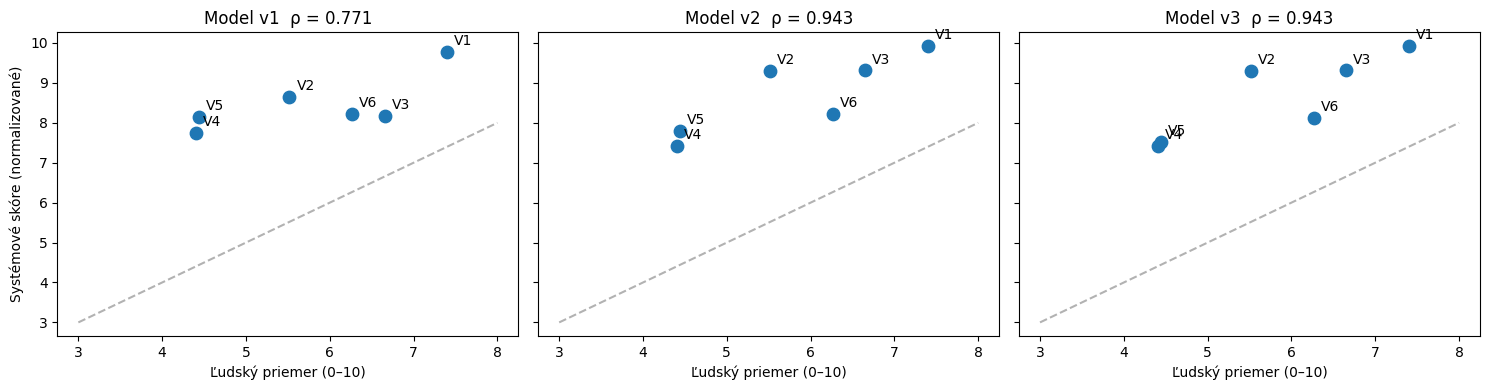

In [6]:
# Vizualizácia: poradie videí — ľudia vs modely
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, model in zip(axes, ['v1', 'v2', 'v3']):
    sys_scores = system_total[model].values
    # Normalizácia 0-100 → 0-10 pre porovnanie na rovnakej škále
    sys_norm = sys_scores / 10
    ax.scatter(human_overall, sys_norm, s=80)
    for v, h, s in zip(VIDEOS, human_overall, sys_norm):
        ax.annotate(v, (h, s), xytext=(5, 5), textcoords='offset points')
    rho = h31_df.loc[model, 'rho']
    ax.set_xlabel('Ľudský priemer (0–10)')
    ax.set_title(f'Model {model}  ρ = {rho:.3f}')
    ax.plot([3, 8], [3, 8], 'k--', alpha=0.3)
axes[0].set_ylabel('Systémové skóre (normalizované)')
plt.tight_layout()
plt.show()

## 4. Bootstrap CI pre rozdiely Δρ

Pri n=6 nie je k dispozícii klasický Steigerov test so správnou strednou silou. Bootstrap dáva aspoň hrubú predstavu o variabilite Δρ.

**Caveat:** Pri 6 pároch obsahuje resampling veľa duplikátov a niektoré bootstrap vzorky majú degenerované distribúcie (všetky body identické, ρ nedefinovaná). Tieto sa preskakujú. Výsledné CI je orientačné, nie konfirmačné.

In [7]:
def bootstrap_delta_rho(human, sys_a, sys_b, n_boot=10000, rng=RNG):
    """95% CI rozdielu rho(b) - rho(a) cez bootstrap resampling párov."""
    n = len(human)
    deltas = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        h = human[idx]
        a = sys_a[idx]
        b = sys_b[idx]
        # Skip degenerované (všetky hodnoty rovnaké)
        if len(set(h)) < 2 or len(set(a)) < 2 or len(set(b)) < 2:
            continue
        ra, _ = spearmanr(h, a)
        rb, _ = spearmanr(h, b)
        if np.isnan(ra) or np.isnan(rb):
            continue
        deltas.append(rb - ra)
    deltas = np.array(deltas)
    return {
        'n_valid': len(deltas),
        'mean': deltas.mean(),
        'ci_low': np.percentile(deltas, 2.5),
        'ci_high': np.percentile(deltas, 97.5),
        'p_zero_or_neg': (deltas <= 0).mean(),  # podiel iterácií, kde v2/v3 nebol lepší
    }

v1 = system_total['v1'].values
v2 = system_total['v2'].values
v3 = system_total['v3'].values

boot_v2_v1 = bootstrap_delta_rho(human_overall, v1, v2)
boot_v3_v1 = bootstrap_delta_rho(human_overall, v1, v3)
boot_v3_v2 = bootstrap_delta_rho(human_overall, v2, v3)

boot_df = pd.DataFrame({
    'Δρ(v2 - v1)': boot_v2_v1,
    'Δρ(v3 - v1)': boot_v3_v1,
    'Δρ(v3 - v2)': boot_v3_v2,
}).T
boot_df.round(4)

,n_valid,mean,ci_low,ci_high,p_zero_or_neg
Δρ(v2 - v1),9999.0,0.2049,0.0,1.0,0.4101
Δρ(v3 - v1),9998.0,0.2093,0.0,1.0,0.4087
Δρ(v3 - v2),9998.0,0.0000,0.0,0.0,1.0000


## 5. LOO-CV pre H3.1

Cieľ: ukázať, že ak by sme váhy odvodili iba z 5 videí (nie zo všetkých 6), stále by zoraďovali šieste video v poradí blízkom ľudskému.

**Postup pre každé held-out video V_i:**
1. OLS regresia `overall ~ eye + body + fluency + voice` na 260 respondent-level záznamoch z ostatných 5 videí.
2. Normalizácia kladných koeficientov tak, aby ich súčet bol 1 → out-of-sample váhy w_i.
3. Aplikácia w_i na **priemerné ľudské hodnotenia dimenzií** held-out videa V_i → predikované overall.
4. Porovnanie s reálnym priemerom overall pre V_i.

Po 6 iteráciách: Spearman(LOO predikcie, ľudské priemery) a MAE.

**Pozn.:** Toto validuje stabilitu **váh** naprieč videami — tj. že regresia z RQ1 negeneralizuje len na sub-dataset. Validácia plnej systémovej pipeline (s per-dim skóre detegovanými systémom) by si vyžadovala per-dim skóre z modelu, ktoré sa dajú dosadiť v krok 3 namiesto ľudských priemerov.

In [8]:
def loo_cv(df, dims=('eye', 'body', 'fluency', 'voice')):
    predictions = {}
    weights_per_fold = {}
    for held_out in VIDEOS:
        train = df[df['video'] != held_out]
        test_means = df[df['video'] == held_out][list(dims)].mean()

        X = train[list(dims)].values
        X = sm.add_constant(X)
        y = train['overall'].values
        ols = sm.OLS(y, X).fit()
        intercept = ols.params[0]
        coefs = ols.params[1:]

        # Predikcia surových koeficientov + interceptu (priame OLS predikovanie)
        pred_overall = intercept + np.dot(coefs, test_means.values)

        # Pre porovnateľnosť so systémovými váhami: normalizované váhy
        pos_coefs = np.maximum(coefs, 0)
        if pos_coefs.sum() > 0:
            norm_weights = pos_coefs / pos_coefs.sum()
        else:
            norm_weights = np.zeros_like(pos_coefs)

        predictions[held_out] = pred_overall
        weights_per_fold[held_out] = dict(zip(dims, norm_weights))
    return predictions, weights_per_fold

loo_preds, loo_weights = loo_cv(df)

loo_summary = pd.DataFrame({
    'human_overall': human_means['overall'],
    'loo_pred': pd.Series(loo_preds),
})
loo_summary['abs_error'] = (loo_summary['human_overall'] - loo_summary['loo_pred']).abs()
loo_summary.round(3)

,human_overall,loo_pred,abs_error
V1,7.404,7.279,0.125
V2,5.519,5.590,0.071
V3,6.654,6.617,0.036
V4,4.404,5.703,1.300
V5,4.442,4.951,0.509
V6,6.269,5.753,0.517


In [9]:
# Spearman a MAE pre LOO predikcie
loo_rho, loo_p = spearmanr(loo_summary['human_overall'], loo_summary['loo_pred'])
loo_mae = loo_summary['abs_error'].mean()
loo_rmse = np.sqrt((loo_summary['abs_error'] ** 2).mean())

print(f'LOO Spearman ρ = {loo_rho:.4f}  (p = {loo_p:.4f})')
print(f'LOO MAE        = {loo_mae:.3f}')
print(f'LOO RMSE       = {loo_rmse:.3f}')
print()
print('Pre porovnanie:')
for m in ['v1', 'v2', 'v3']:
    print(f'  System {m}: ρ = {h31_df.loc[m, "rho"]:.4f}')

LOO Spearman ρ = 0.8286  (p = 0.0416)
LOO MAE        = 0.426
LOO RMSE       = 0.611

Pre porovnanie:
  System v1: ρ = 0.7714
  System v2: ρ = 0.9429
  System v3: ρ = 0.9429


In [10]:
# Stabilita váh naprieč LOO foldami — kontrola, či nie sú extrémne citlivé na výber videí
weights_df = pd.DataFrame(loo_weights).T
weights_df.loc['stred'] = weights_df.mean()
weights_df.loc['SD'] = weights_df.iloc[:6].std()
weights_df.round(3)

,eye,body,fluency,voice
V1,0.299,0.107,0.247,0.348
V2,0.245,0.127,0.261,0.368
V3,0.331,0.056,0.235,0.377
V4,0.382,0.194,0.332,0.092
V5,0.302,0.135,0.165,0.398
V6,0.260,0.118,0.283,0.339
stred,0.303,0.123,0.254,0.320
SD,0.049,0.045,0.055,0.114


## 6. H3.2 — Distribučná penalizácia na dimenzii plynulosti

Test: Modely v2 a v3 sa líšia iba v tom, či penalizujú **rovnomerne rozložené** výplňové slová viac ako sústredené (v3 áno, v2 nie). Porovnávame, ktorá fluency Δ medzi V5 a V6 je bližšie k pozorovanému ľudskému Δ na **dimenzii plynulosti**.

Ostatné videá nie sú v H3.2 relevantné (jediná rozhodujúca kontrast je rovnomerne vs sústredene).

In [11]:
# Ľudské hodnotenia plynulosti pre V5 a V6
h_v5 = df[df['video'] == 'V5']['fluency'].values
h_v6 = df[df['video'] == 'V6']['fluency'].values

# Párový t-test (rovnaký respondent hodnotil V5 aj V6)
df_v5 = df[df['video'] == 'V5'].set_index('respondent_id')['fluency']
df_v6 = df[df['video'] == 'V6'].set_index('respondent_id')['fluency']
paired = pd.concat([df_v5.rename('V5'), df_v6.rename('V6')], axis=1).dropna()

t_stat, t_p = ttest_rel(paired['V5'], paired['V6'])
w_stat, w_p = wilcoxon(paired['V5'], paired['V6'])

print(f'Ľudské hodnotenie plynulosti:')
print(f'  V5 (rovnomerne): {paired["V5"].mean():.2f} ± {paired["V5"].std():.2f}')
print(f'  V6 (sústredene): {paired["V6"].mean():.2f} ± {paired["V6"].std():.2f}')
print(f'  Δ (V5 − V6)    : {(paired["V5"] - paired["V6"]).mean():.3f}')
print(f'  Párový t-test  : t = {t_stat:.3f}, p = {t_p:.6f}')
print(f'  Wilcoxon       : W = {w_stat:.1f}, p = {w_p:.6f}')

Ľudské hodnotenie plynulosti:
  V5 (rovnomerne): 3.63 ± 1.97
  V6 (sústredene): 5.27 ± 2.28
  Δ (V5 − V6)    : -1.635
  Párový t-test  : t = -5.864, p = 0.000000
  Wilcoxon       : W = 68.5, p = 0.000001


In [12]:
# Porovnanie Δ-fluency v rôznych modeloch (na škále 0–10)
human_delta = paired['V5'].mean() - paired['V6'].mean()

rows = []
for m in ['v1', 'v2', 'v3']:
    sys_v5 = system_fluency.loc['V5', m] / 10  # 0–100 → 0–10
    sys_v6 = system_fluency.loc['V6', m] / 10
    sys_delta = sys_v5 - sys_v6
    abs_err = abs(sys_delta - human_delta)
    rows.append({
        'model': m,
        'sys_V5_fluency': sys_v5,
        'sys_V6_fluency': sys_v6,
        'sys_Δ': sys_delta,
        'human_Δ': human_delta,
        '|sys_Δ - human_Δ|': abs_err,
        'pomer sys_Δ / human_Δ': sys_delta / human_delta if human_delta != 0 else np.nan,
    })

h32_df = pd.DataFrame(rows).set_index('model')
h32_df.round(3)

,sys_V5_fluency,sys_V6_fluency,sys_Δ,human_Δ,|sys_Δ - human_Δ|,pomer sys_Δ / human_Δ
model,,,,,,
v1,3.93,5.55,-1.62,-1.635,0.015,0.991
v2,3.93,5.55,-1.62,-1.635,0.015,0.991
v3,2.95,5.19,-2.24,-1.635,0.605,1.370


In [13]:
# Verdikt H3.2 — bližší model k ľudskému Δ
best_model = h32_df['|sys_Δ - human_Δ|'].idxmin()
print(f'Model najbližšie k ľudskému Δ na fluency: {best_model}')
print(f'  |Δ_sys - Δ_human| = {h32_df.loc[best_model, "|sys_Δ - human_Δ|"]:.3f}')
print()
print('Ranking absolútnej chyby (menšie = bližšie k ľuďom):')
print(h32_df['|sys_Δ - human_Δ|'].sort_values().round(3).to_string())

Model najbližšie k ľudskému Δ na fluency: v1
  |Δ_sys - Δ_human| = 0.015

Ranking absolútnej chyby (menšie = bližšie k ľuďom):
model
v1    0.015
v2    0.015
v3    0.605


## 7. Zhrnutie pre HYPOTHESES.md

Hodnoty na vloženie do sekcie *RQ3 — Validácia hodnotiaceho systému voči ľudskému vnímaniu*.

In [14]:
print('=' * 60)
print('H3.1 — Spearmanove korelácie')
print('=' * 60)
for m in ['v1', 'v2', 'v3']:
    rho = h31_df.loc[m, 'rho']
    p = h31_df.loc[m, 'p']
    print(f'  Model {m}: ρ = {rho:.4f}, p = {p:.4f}')
print()
print(f'Bootstrap 95% CI rozdielov:')
for label, b in [('Δρ(v2 − v1)', boot_v2_v1), ('Δρ(v3 − v1)', boot_v3_v1), ('Δρ(v3 − v2)', boot_v3_v2)]:
    print(f'  {label}: stred = {b["mean"]:+.3f}, CI = [{b["ci_low"]:+.3f}, {b["ci_high"]:+.3f}]')
print()
print('=' * 60)
print('LOO-CV (out-of-sample váhy)')
print('=' * 60)
print(f'  Spearman ρ = {loo_rho:.4f} (p = {loo_p:.4f})')
print(f'  MAE        = {loo_mae:.3f}')
print(f'  RMSE       = {loo_rmse:.3f}')
print()
print('=' * 60)
print('H3.2 — Distribučná penalizácia (fluency dimenzia, V5 vs V6)')
print('=' * 60)
print(f'  Ľudské Δ (V5 − V6) na fluency: {human_delta:+.3f}')
print(f'  Párový t-test: t = {t_stat:.3f}, p = {t_p:.6f}')
for m in ['v1', 'v2', 'v3']:
    err = h32_df.loc[m, '|sys_Δ - human_Δ|']
    sd = h32_df.loc[m, 'sys_Δ']
    print(f'  Model {m}: sys_Δ = {sd:+.3f}, |chyba| = {err:.3f}')
print()
print(f'Najbližší ľudskému Δ: model {best_model}')

H3.1 — Spearmanove korelácie
  Model v1: ρ = 0.7714, p = 0.0724
  Model v2: ρ = 0.9429, p = 0.0048
  Model v3: ρ = 0.9429, p = 0.0048

Bootstrap 95% CI rozdielov:
  Δρ(v2 − v1): stred = +0.205, CI = [+0.000, +1.000]
  Δρ(v3 − v1): stred = +0.209, CI = [+0.000, +1.000]
  Δρ(v3 − v2): stred = +0.000, CI = [+0.000, +0.000]

LOO-CV (out-of-sample váhy)
  Spearman ρ = 0.8286 (p = 0.0416)
  MAE        = 0.426
  RMSE       = 0.611

H3.2 — Distribučná penalizácia (fluency dimenzia, V5 vs V6)
  Ľudské Δ (V5 − V6) na fluency: -1.635
  Párový t-test: t = -5.864, p = 0.000000
  Model v1: sys_Δ = -1.620, |chyba| = 0.015
  Model v2: sys_Δ = -1.620, |chyba| = 0.015
  Model v3: sys_Δ = -2.240, |chyba| = 0.605

Najbližší ľudskému Δ: model v1


## 8. Limitations

Pri prezentácii výsledkov RQ3 je potrebné priznať tieto obmedzenia:

1. **n = 6 videí** je veľmi malá vzorka pre rank koreláciu. Aj p < 0.01 znamená iba, že súčasné poradie je nepravdepodobné pri náhodnom usporiadaní zo 720 možných permutácií — generalizácia mimo testovaných manipulácií je obmedzená.
2. **Bootstrap CI pre Δρ je orientačné.** Pri n = 6 je distribúcia diskrétna a CI sú široké; nepoužívajú sa ako konfirmačný test.
3. **In-corpus validácia.** Aj LOO-CV ostáva v rovnakom korpuse 6 videí, kde dimenzionálne charakteristiky boli kontrolované manipuláciou. Externý korpus nezávislých prezentácií je future work.
4. **Spearman ignoruje kalibráciu.** Systém systematicky nadhodnocuje absolútne hodnoty (~25–30 bodov nad ľudským priemerom). Pre kalibráciu bude potrebná škálovacia transformácia, čo je tiež future work.
5. **H3.2 testovaný len na výplňových slovách.** Distribučná penalizácia bola overená iba na jednom jave; generalizácia na ďalšie negatívne javy (monotónny hlas, slabý očný kontakt v sústrednom úseku) si vyžaduje samostatné prieskumy.